In [1]:
#importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#dataset loading
df=pd.read_csv("ai_task_management_200k.csv")

In [3]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200000, 35)


,record_id,age_group,age,gender,activity,category,task_level,parent_task,task_category,day_of_week,...,notes,description,deadline_label,urgency_score,importance,priority_score,energy_level,category_ml,task_completed,cleaned_text
0,REC000001,Adult,38,Male,Health,Health & Wellness,Medium,Health Goals,Goal,Friday,...,Focus needed,Moving quickly through the preventive health a...,Next Week,6,10,7.60,Very High,Learning,True,moving quickly preventive health activity targ...
1,REC000002,Senior,69,Non-binary,Meditation,Health & Wellness,Medium,Learning Path,One-time,Sunday,...,Review before starting,Making steady progress on the daily mindfulnes...,Overdue,9,4,6.00,Very High,Social,True,making steady progress daily mindfulness routi...
2,REC000003,Middle-Aged,51,Male,Cleaning,Household,Expert,Social Events,Habit,Tuesday,...,Requires equipment,Having a hard time starting the household clea...,This Month,5,6,5.88,High,Finance,False,having hard time starting household cleaning r...
3,REC000004,Adult,40,Female,Health,Health & Wellness,Easy,Learning Path,Habit,Monday,...,Check progress,"Lacking enthusiasm but staying committed, Calm...",No Deadline,2,5,3.14,Low,Other,True,lacking enthusiasm staying committed calmly ha...
4,REC000005,Young Adult,21,Female,Cleaning,Household,Easy,Social Events,Recurring,Friday,...,Review before starting,Staying on track with the home maintenance act...,Tomorrow,7,3,5.45,Medium,Health,True,staying track home maintenance activity adequa...


In [4]:
#basic dataset info
print("\nDataset Info")
df.info()


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 35 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   record_id         200000 non-null  object 
 1   age_group         200000 non-null  object 
 2   age               200000 non-null  int64  
 3   gender            200000 non-null  object 
 4   activity          200000 non-null  object 
 5   category          200000 non-null  object 
 6   task_level        200000 non-null  object 
 7   parent_task       200000 non-null  object 
 8   task_category     200000 non-null  object 
 9   day_of_week       200000 non-null  object 
 10  time_slot         200000 non-null  object 
 11  duration_minutes  200000 non-null  int64  
 12  priority          200000 non-null  object 
 13  status            200000 non-null  object 
 14  mood              200000 non-null  object 
 15  location          200000 non-null  object 
 16  season

In [5]:
print("\nMissing Values")
df.isnull().sum()


Missing Values


record_id               0
age_group               0
age                     0
gender                  0
activity                0
category                0
task_level              0
parent_task             0
task_category           0
day_of_week             0
time_slot               0
duration_minutes        0
priority                0
status                  0
mood                    0
location                0
season                  0
is_routine              0
is_digital              0
is_physical             0
task_date               0
scheduled_time          0
completed_time      70000
reminder_set            0
repeat_frequency    89666
notes                   0
description             0
deadline_label          0
urgency_score           0
importance              0
priority_score          0
energy_level            0
category_ml             0
task_completed          0
cleaned_text            0
dtype: int64

In [6]:
print("\nStatistical Summary")
df.describe()


Statistical Summary


,age,duration_minutes,urgency_score,importance,priority_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,39.042155,72.574715,5.018980,5.496410,5.258661
std,16.234600,63.113810,2.467012,2.876364,1.910474
min,13.000000,10.000000,1.000000,1.000000,1.000000
25%,26.000000,24.000000,3.000000,3.000000,3.880000
50%,38.000000,55.000000,5.000000,5.000000,5.260000
75%,51.000000,90.000000,7.000000,8.000000,6.630000
max,79.000000,299.000000,9.000000,10.000000,10.000000


In [7]:
#handling missing values
# Fill numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [8]:
# Fill categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [9]:
df['age_group'].value_counts()

age_group
Adult          59888
Middle-Aged    50289
Young Adult    49928
Teen           20020
Senior         19875
Name: count, dtype: int64

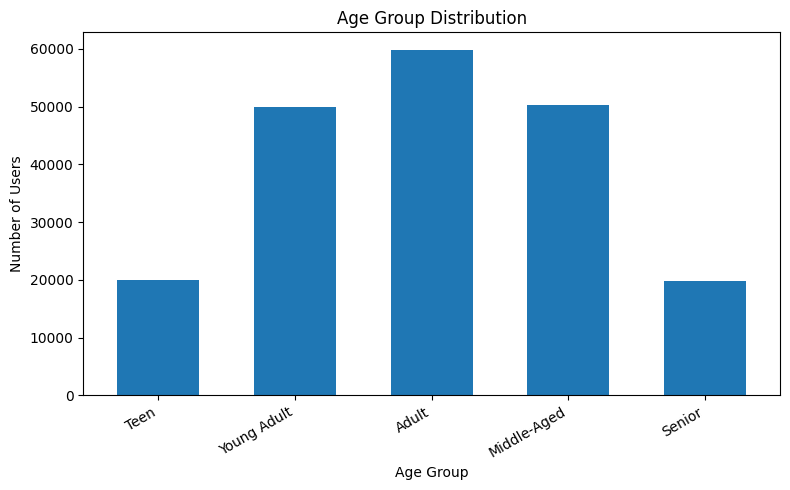

In [10]:
#age group distribution
%matplotlib inline

age_order = [
    'Teen',
    'Young Adult',
    'Adult',
    'Middle-Aged',
    'Senior'
]

plt.figure(figsize=(8, 5))

counts = df['age_group'].value_counts().reindex(age_order)

counts.plot(kind='bar', width=0.6)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

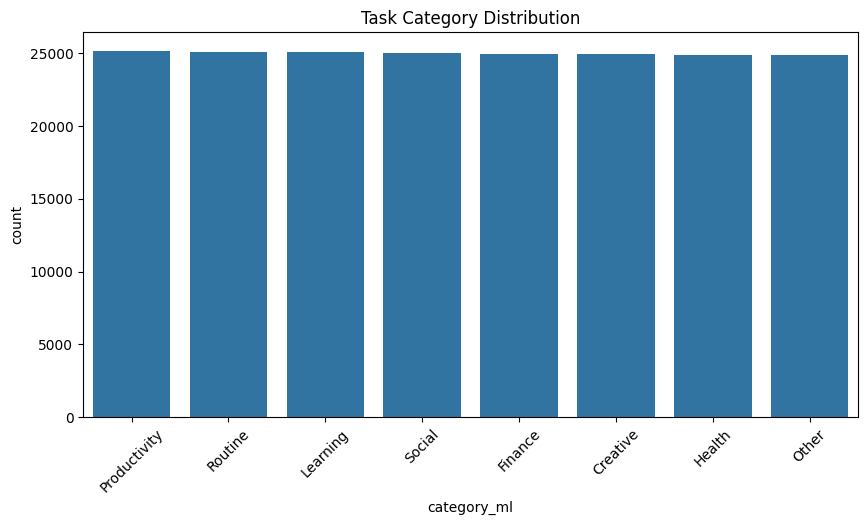

In [11]:
#task category distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="category_ml", order=df["category_ml"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Task Category Distribution")
plt.show()

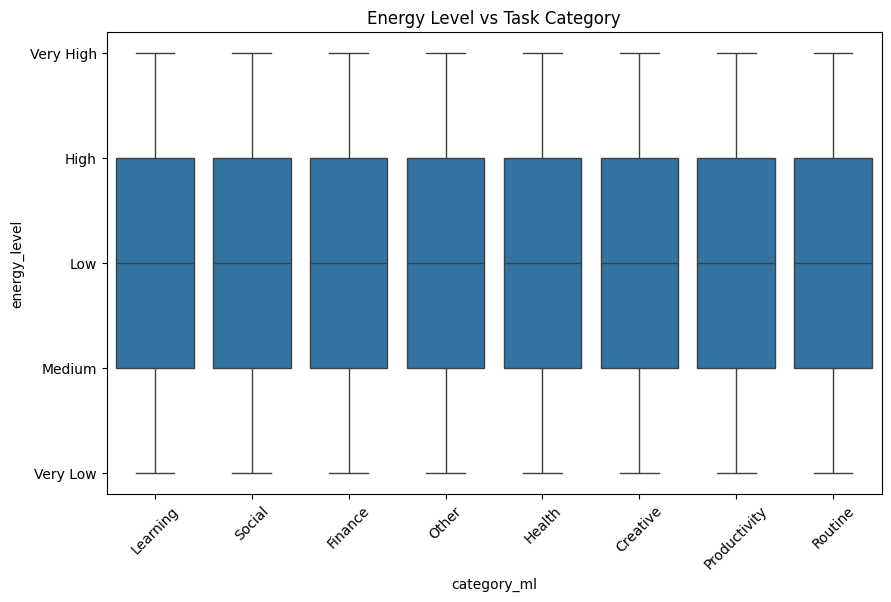

In [12]:
#Energy Level vs Task Category
plt.figure(figsize=(10,6))
sns.boxplot(x="category_ml", y="energy_level", data=df)
plt.xticks(rotation=45)
plt.title("Energy Level vs Task Category")
plt.show()

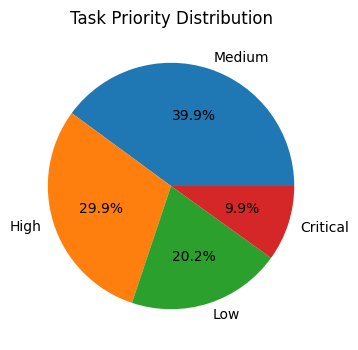

In [13]:
#Task Priority Analysis
if "priority" in df.columns:
    plt.figure(figsize=(6,4))
    df['priority'].value_counts().plot(kind='pie', autopct="%1.1f%%")
    plt.title("Task Priority Distribution")
    plt.ylabel("")
    plt.show()

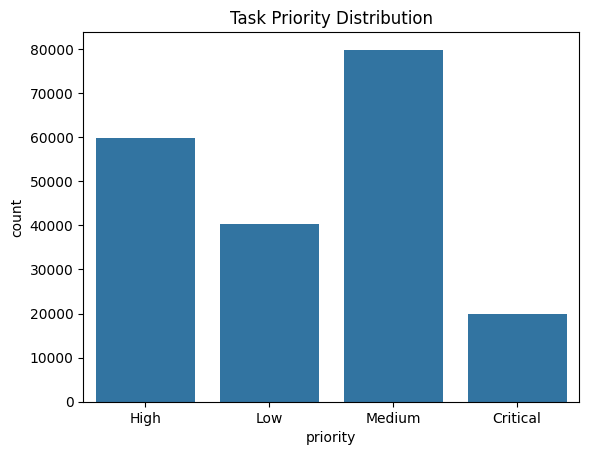

In [14]:
sns.countplot(x='priority', data=df)
plt.title("Task Priority Distribution")
plt.show()

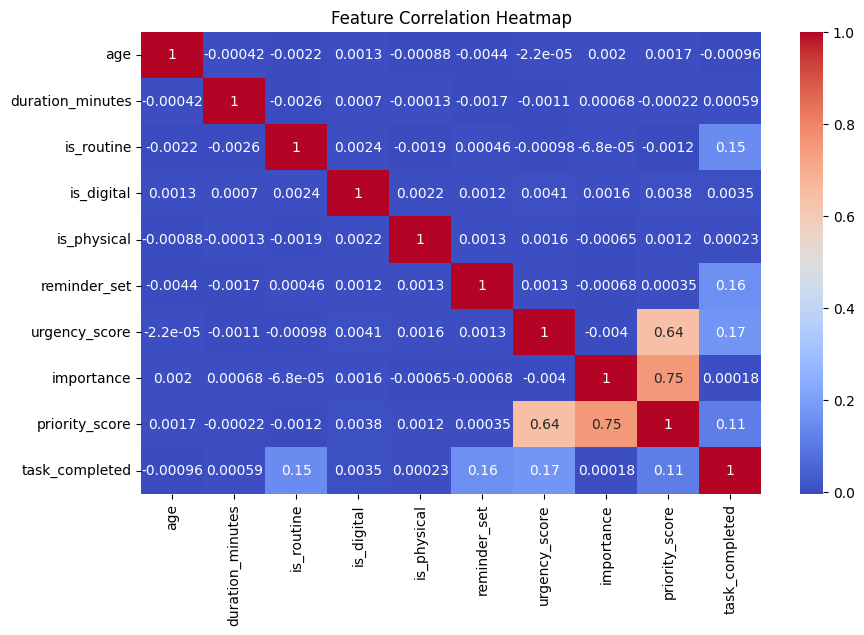

In [15]:
#Correlation Analysis
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

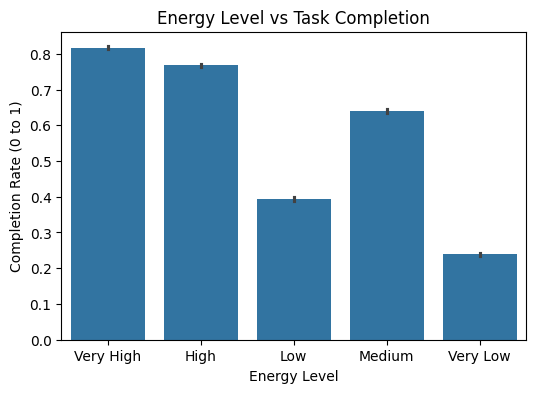


📊 Completion Rate per Energy Level:
  High       : 76.7% tasks completed
  Low        : 39.4% tasks completed
  Medium     : 64.1% tasks completed
  Very High  : 81.7% tasks completed
  Very Low   : 23.9% tasks completed


In [16]:
#Productivity Insights
df['task_completed'] = (df['status'] == 'Completed').astype(int)
plt.figure(figsize=(6, 4))
sns.barplot(x="energy_level",
            y="task_completed",
            data=df)
plt.title("Energy Level vs Task Completion")
plt.xlabel("Energy Level")
plt.ylabel("Completion Rate (0 to 1)")
plt.show()
print("\n📊 Completion Rate per Energy Level:")
result = df.groupby('energy_level')['task_completed'].mean().round(3) * 100
for energy, rate in result.items():
    print(f"  {energy:<10} : {rate:.1f}% tasks completed")

In [17]:
df.columns

Index(['record_id', 'age_group', 'age', 'gender', 'activity', 'category',
       'task_level', 'parent_task', 'task_category', 'day_of_week',
       'time_slot', 'duration_minutes', 'priority', 'status', 'mood',
       'location', 'season', 'is_routine', 'is_digital', 'is_physical',
       'task_date', 'scheduled_time', 'completed_time', 'reminder_set',
       'repeat_frequency', 'notes', 'description', 'deadline_label',
       'urgency_score', 'importance', 'priority_score', 'energy_level',
       'category_ml', 'task_completed', 'cleaned_text'],
      dtype='object')

In [18]:
df[['description', 'activity', 'parent_task']].head(10)

,description,activity,parent_task
0,Moving quickly through the preventive health a...,Health,Health Goals
1,Making steady progress on the daily mindfulnes...,Meditation,Learning Path
2,Having a hard time starting the household clea...,Cleaning,Social Events
3,"Lacking enthusiasm but staying committed, Calm...",Health,Learning Path
4,Staying on track with the home maintenance act...,Cleaning,Social Events
5,Having a hard time starting the relationship b...,Social,Morning Routine
6,Following the plan for the sleep schedule opti...,Sleep,Learning Path
7,Calmly handling the skill-based game challenge...,Gaming,Health Goals
8,Despite feeling tired and low energy despite l...,Cooking,Social Events
9,Staying on track with the relationship buildin...,Social,Project Alpha


In [19]:
df['text']=df['description']
df['text'].head()

0    Moving quickly through the preventive health a...
1    Making steady progress on the daily mindfulnes...
2    Having a hard time starting the household clea...
3    Lacking enthusiasm but staying committed, Calm...
4    Staying on track with the home maintenance act...
Name: text, dtype: object

In [20]:
print(df['description'].nunique())

168507


In [21]:
#NLP preprocessing 
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)

df[['text', 'cleaned_text']].head()

,text,cleaned_text
0,Moving quickly through the preventive health a...,moving quickly preventive health activity targ...
1,Making steady progress on the daily mindfulnes...,making steady progress daily mindfulness routi...
2,Having a hard time starting the household clea...,hard time starting household cleaning routine ...
3,"Lacking enthusiasm but staying committed, Calm...",lacking enthusiasm staying committed calmly ha...
4,Staying on track with the home maintenance act...,staying track home maintenance activity adequa...


In [40]:
#TFIDF feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

TfidfVectorizer(max_features=300)
X = tfidf.fit_transform(df['cleaned_text']).toarray()

In [23]:
#target variable
y = df['task_completed'].astype(int)

In [24]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# Naive Bayes model
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score   # <-- ADD THIS LINE

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred_nb)*100)

Model Accuracy: 79.065


In [26]:
#random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=50,     # default = 100 → reduce trees
    max_depth=10,        # limit depth (very important)
    n_jobs=-1,           # use all CPU cores (BIG speed boost)
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, pred)*100)

Model Accuracy: 78.9875


In [27]:
#SVM model
from sklearn.svm import LinearSVC 
svm_model = LinearSVC(max_iter=3000, C=1.0)
svm_model.fit(X_train, y_train) 
y_pred_svm = svm_model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred_svm)*100)

Model Accuracy: 80.55499999999999


In [28]:
#evaluation(accuracy and classification report)
from sklearn.metrics import accuracy_score, classification_report

print("----- NAIVE BAYES -----")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

print("-----RANDOM FOREST-----")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

print("\n----- SVM -----")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

----- NAIVE BAYES -----
Accuracy: 0.79065
              precision    recall  f1-score   support

           0       0.86      0.61      0.71     17036
           1       0.76      0.93      0.84     22964

    accuracy                           0.79     40000
   macro avg       0.81      0.77      0.77     40000
weighted avg       0.80      0.79      0.78     40000

-----RANDOM FOREST-----
Accuracy: 0.789875
              precision    recall  f1-score   support

           0       0.81      0.66      0.73     17036
           1       0.78      0.88      0.83     22964

    accuracy                           0.79     40000
   macro avg       0.79      0.77      0.78     40000
weighted avg       0.79      0.79      0.79     40000


----- SVM -----
Accuracy: 0.80555
              precision    recall  f1-score   support

           0       0.83      0.69      0.75     17036
           1       0.79      0.89      0.84     22964

    accuracy                           0.81     40000
   macro

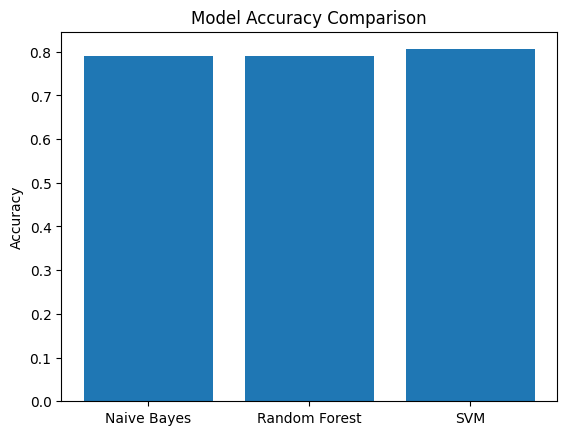

In [29]:
#Model Comparison Graph
models = ['Naive Bayes', 'Random Forest','SVM']
accuracies = [
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, pred),
    accuracy_score(y_test, y_pred_svm)
]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [30]:
#Overfitting check for naive bayes 
from sklearn.metrics import accuracy_score

train_acc_nb = accuracy_score(y_train, nb_model.predict(X_train))
test_acc_nb  = accuracy_score(y_test,  nb_model.predict(X_test))

print("----- NAIVE BAYES -----")
print(f"Train Accuracy : {train_acc_nb*100:.2f}%")
print(f"Test  Accuracy : {test_acc_nb*100:.2f}%")
print(f"Difference     : {(train_acc_nb - test_acc_nb)*100:.2f}%")

if (train_acc_nb - test_acc_nb) < 0.02:
    print("✅ No overfitting — model generalizes well!\n")
elif (train_acc_nb - test_acc_nb) < 0.05:
    print("⚠️ Slight overfitting — minor tuning needed\n")
else:
    print("🚨 Overfitting detected — needs fixing!\n")

----- NAIVE BAYES -----
Train Accuracy : 78.90%
Test  Accuracy : 79.06%
Difference     : -0.16%
✅ No overfitting — model generalizes well!



In [31]:
#overfitting check for random forest
train_acc_rf = accuracy_score(y_train, model.predict(X_train))
test_acc_rf  = accuracy_score(y_test,  model.predict(X_test))

print("----- RANDOM FOREST -----")
print(f"Train Accuracy : {train_acc_rf*100:.2f}%")
print(f"Test  Accuracy : {test_acc_rf*100:.2f}%")
print(f"Difference     : {(train_acc_rf - test_acc_rf)*100:.2f}%")

if (train_acc_rf - test_acc_rf) < 0.02:
    print("✅ No overfitting — model generalizes well!")
elif (train_acc_rf - test_acc_rf) < 0.05:
    print("⚠️ Slight overfitting — minor tuning needed")
else:
    print("🚨 Overfitting detected — needs fixing!")

----- RANDOM FOREST -----
Train Accuracy : 79.05%
Test  Accuracy : 78.99%
Difference     : 0.06%
✅ No overfitting — model generalizes well!


In [32]:
#Overfitting check for SVM
train_acc_svm = accuracy_score(y_train, svm_model.predict(X_train))
test_acc_svm  = accuracy_score(y_test,  svm_model.predict(X_test))

print("----- SVM -----")
print(f"Train Accuracy : {train_acc_svm*100:.2f}%")
print(f"Test  Accuracy : {test_acc_svm*100:.2f}%")
print(f"Difference     : {(train_acc_svm - test_acc_svm)*100:.2f}%")

if (train_acc_svm - test_acc_svm) < 0.02:
    print("✅ No overfitting — model generalizes well!")
elif (train_acc_svm - test_acc_svm) < 0.05:
    print("⚠️ Slight overfitting — minor tuning needed")
else:
    print("🚨 Overfitting detected — needs fixing!")

----- SVM -----
Train Accuracy : 80.59%
Test  Accuracy : 80.55%
Difference     : 0.03%
✅ No overfitting — model generalizes well!


In [33]:
#pkl file generation
import pickle

with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Models saved successfully!")

✅ Models saved successfully!


In [34]:
import os
print(os.getcwd())

C:\Users\krishna gupta\Desktop\AI_Powered_Task_management_system\AI-Task-Management-ML


In [35]:
# Prediction on new task
new_tasks = [
    "Complete project report urgently before deadline",
    "Watch movie in evening",
    "Prepare for exam tomorrow",
    "Go for a morning workout session",
    "Pay electricity bill before due date",
    "Clean the house on weekend",
    "Read book before sleeping tonight",
    "Finish client presentation by Friday"
]

print("Task Completion based on priority------>")
print("=" * 120)
print(f"{'TASK':<40} {'NB':^10} {'RF':^10} {'SVM':^10}")
print("=" * 120)

for task in new_tasks:
    new_cleaned  = [preprocess_text(task)]
    new_X        = tfidf.transform(new_cleaned).toarray()
    nb_pred      = nb_model.predict(new_X)[0]
    pred         = model.predict(new_X)[0]
    svm_pred     = svm_model.predict(new_X)[0]
    nb_label     = "✅ Done" if nb_pred  == 1 else "❌ Not Done"
    label        = "✅ Done" if pred  == 1 else "❌ Not Done"
    svm_label    = "✅ Done" if svm_pred == 1 else "❌ Not Done"
    print(f"{task:<40} {nb_label:^10} {label:^10} {svm_label:^10}")

print("=" * 120)

Task Completion based on priority------>
TASK                                         NB         RF        SVM    
Complete project report urgently before deadline   ✅ Done     ✅ Done     ✅ Done  
Watch movie in evening                     ✅ Done     ✅ Done   ❌ Not Done
Prepare for exam tomorrow                  ✅ Done     ✅ Done     ✅ Done  
Go for a morning workout session           ✅ Done     ✅ Done   ❌ Not Done
Pay electricity bill before due date       ✅ Done     ✅ Done     ✅ Done  
Clean the house on weekend                 ✅ Done     ✅ Done   ❌ Not Done
Read book before sleeping tonight          ✅ Done     ✅ Done   ❌ Not Done
Finish client presentation by Friday       ✅ Done     ✅ Done   ❌ Not Done


In [36]:
def assign_priority(deadline):
    if deadline < 2:
        return "High"
    elif deadline < 5:
        return "Medium"
    else:
        return "Low"

In [37]:
model = RandomForestClassifier(n_estimators=50, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
team = {
    "A": 3,
    "B": 5,
    "C": 2
}

# assign to least loaded
assigned = min(team, key=team.get)
team[assigned] += 1

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}

grid = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=params,
    n_iter=4,
    cv=3,
    n_jobs=-1,
    random_state=42
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'n_estimators': 50, 'max_depth': 20}


In [41]:
import joblib
joblib.dump(model, "priority_model.pkl")

['priority_model.pkl']

In [42]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [44]:
print(df["category"].value_counts())

category
Health & Wellness    40017
Personal             39967
Household            26748
Entertainment        26638
Finance              13436
Social               13399
Professional         13352
Travel               13325
Education            13118
Name: count, dtype: int64
